In [18]:
# Unit homework.  problems 15.2 (pages 401-402)

In [19]:
# load required libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pylab as plt
import seaborn as sns

In [20]:
from pandas.core.apply import frame_apply
from sklearn.preprocessing import MinMaxScaler

In [21]:
# Load the data and see its shape
pharm = pd.read_csv('Pharmaceuticals.csv')
pharm.shape

(21, 14)

In [22]:
print(pharm)

   Symbol                                Name  Market_Cap  Beta  PE_Ratio  \
0     ABT                 Abbott Laboratories       68.44  0.32      24.7   
1     AGN                      Allergan, Inc.        7.58  0.41      82.5   
2     AHM                        Amersham plc        6.30  0.46      20.7   
3     AZN                     AstraZeneca PLC       67.63  0.52      21.5   
4     AVE                             Aventis       47.16  0.32      20.1   
5     BAY                            Bayer AG       16.90  1.11      27.9   
6     BMY        Bristol-Myers Squibb Company       51.33  0.50      13.9   
7    CHTT                        Chattem, Inc        0.41  0.85      26.0   
8     ELN               Elan Corporation, plc        0.78  1.08       3.6   
9     LLY               Eli Lilly and Company       73.84  0.18      27.9   
10    GSK                 GlaxoSmithKline plc      122.11  0.35      18.0   
11    IVX                    IVAX Corporation        2.60  0.65      19.9   

In [23]:
pharm2 = pharm

In [24]:
pharm2 = pharm2.drop(columns=['Symbol', 'Median_Recommendation', 'Location', 'Exchange'])

In [25]:
pharm2

,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
0,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1
1,"Allergan, Inc.",7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5
2,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2
3,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0
4,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9
5,Bayer AG,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6
6,Bristol-Myers Squibb Company,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6
7,"Chattem, Inc",0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5
8,"Elan Corporation, plc",0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3
9,Eli Lilly and Company,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4


In [26]:
pharm2.set_index('Name', inplace=True)

In [27]:
pharm2 = pharm2.apply(lambda x: x.astype('float64'))

In [28]:
d = pairwise.pairwise_distances(pharm2, metric='euclidean')
pd.DataFrame(d, columns=pharm2.index, index= pharm2.index)

Name,Abbott Laboratories,"Allergan, Inc.",Amersham plc,AstraZeneca PLC,Aventis,Bayer AG,Bristol-Myers Squibb Company,"Chattem, Inc","Elan Corporation, plc",Eli Lilly and Company,...,IVAX Corporation,Johnson & Johnson,Medicis Pharmaceutical Corporation,"Merck & Co., Inc.",Novartis AG,Pfizer Inc,Pharmacia Corporation,Schering-Plough Corporation,"Watson Pharmaceuticals, Inc.",Wyeth
Name,,,,,,,,,,,,,,,,,,,,,
Abbott Laboratories,0.000000,85.917312,63.639310,9.185538,29.920523,59.822957,23.121691,69.111906,76.915243,10.888094,...,66.908429,105.705586,73.193453,66.763236,31.977390,134.165821,38.688666,35.115217,71.027789,38.729072
"Allergan, Inc.",85.917312,0.000000,62.186991,88.464627,76.876489,57.681984,86.380224,58.232457,83.461502,89.957867,...,63.811828,176.398183,60.406150,143.748674,110.119469,205.437625,55.513006,71.065817,68.042352,93.647162
Amersham plc,63.639310,62.186991,0.000000,63.918213,45.946291,22.475627,51.289521,13.584944,32.766910,71.098335,...,10.358673,168.728623,27.469658,129.505589,91.679208,197.315603,62.133132,30.148723,23.297678,60.778118
AstraZeneca PLC,9.185538,88.464627,63.918213,0.000000,26.086061,62.693619,23.166253,69.785040,73.753950,14.247972,...,66.284617,106.683038,71.233416,66.467431,35.813810,133.771670,41.913590,34.642670,68.794387,38.479341
Aventis,29.920523,76.876489,45.946291,26.086061,0.000000,48.371042,30.386614,51.891976,50.300347,37.788465,...,46.428300,128.811970,48.838491,88.292099,58.660169,155.135426,40.624857,23.698688,45.559224,45.161354
Bayer AG,59.822957,57.681984,22.475627,62.693619,48.371042,0.000000,53.695147,28.628313,50.024640,68.152431,...,31.164719,160.880810,42.331739,124.676208,84.171984,191.680271,53.189389,35.087503,39.353894,66.943706
Bristol-Myers Squibb Company,23.121691,86.380224,51.289521,23.166253,30.386614,53.695147,0.000000,56.252955,64.781162,27.203937,...,53.661661,123.826053,64.395869,83.150232,49.465348,150.718366,52.050423,22.751429,61.129615,21.149340
"Chattem, Inc",69.111906,58.232457,13.584944,69.785040,51.891976,28.628313,56.252955,0.000000,37.386927,76.092004,...,11.401395,174.379387,30.785071,134.445187,98.408184,202.500868,65.162040,37.254721,29.228081,62.022490
"Elan Corporation, plc",76.915243,83.461502,32.766910,73.753950,50.300347,50.024640,64.781162,37.386927,0.000000,84.491569,...,26.946987,177.604964,26.820710,136.509584,104.911292,203.038957,79.266869,46.324234,16.796839,72.703821


In [29]:
pharm2_norm = pharm2.apply(preprocessing.scale, axis = 0)

pharm2_norm = (pharm2 - pharm2.mean())/ pharm2.std()

pharm2_norm [['Market_Cap', 'Net_Profit_Margin']]
d_norm = pairwise.pairwise_distances(pharm2_norm[['Market_Cap', 'Net_Profit_Margin']],
                                                  metric= 'euclidean')
pd.DataFrame(d_norm, columns=pharm2.index, index=pharm2.index)

Name,Abbott Laboratories,"Allergan, Inc.",Amersham plc,AstraZeneca PLC,Aventis,Bayer AG,Bristol-Myers Squibb Company,"Chattem, Inc","Elan Corporation, plc",Eli Lilly and Company,...,IVAX Corporation,Johnson & Johnson,Medicis Pharmaceutical Corporation,"Merck & Co., Inc.",Novartis AG,Pfizer Inc,Pharmacia Corporation,Schering-Plough Corporation,"Watson Pharmaceuticals, Inc.",Wyeth
Name,,,,,,,,,,,,,,,,,,,,,
Abbott Laboratories,0.000000,1.920381,1.296897,0.289873,0.607999,2.237387,0.745327,1.750768,1.230875,1.116267,...,1.366115,1.820860,1.394432,1.135800,1.073987,2.631032,1.357107,0.628984,1.122622,1.473567
"Allergan, Inc.",1.920381,0.000000,0.868906,2.163010,1.314479,0.469680,2.419183,0.328423,1.194303,2.952850,...,0.842450,3.410045,2.410245,2.503160,2.990456,4.442344,0.874469,1.898655,1.464814,3.125615
Amersham plc,1.296897,0.868906,0.000000,1.472777,0.743808,1.322990,1.625553,0.572736,0.333596,2.187417,...,0.070108,3.037199,1.541612,2.199357,2.300010,3.926449,1.038955,1.084553,0.596586,2.293438
AstraZeneca PLC,0.289873,2.163010,1.472777,0.000000,0.852082,2.501392,0.484099,1.968770,1.346944,0.829709,...,1.539254,1.813966,1.240105,1.257302,0.833559,2.503020,1.642131,0.575393,1.183980,1.190102
Aventis,0.607999,1.314479,0.743808,0.852082,0.000000,1.652383,1.175570,1.146114,0.793772,1.663617,...,0.813634,2.293473,1.501230,1.468693,1.676026,3.204421,0.867344,0.750109,0.820710,1.920213
Bayer AG,2.237387,0.469680,1.322990,2.501392,1.652383,0.000000,2.805258,0.797976,1.653627,3.315315,...,1.303138,3.551948,2.862285,2.639401,3.310034,4.644028,0.981651,2.304637,1.919060,3.530373
Bristol-Myers Squibb Company,0.745327,2.419183,1.625553,0.484099,1.175570,2.805258,0.000000,2.177225,1.407698,0.574117,...,1.682761,2.132123,0.862043,1.703664,0.820547,2.623256,2.028537,0.543555,1.172747,0.748638
"Chattem, Inc",1.750768,0.328423,0.572736,1.968770,1.146114,0.797976,2.177225,0.000000,0.883893,2.727833,...,0.534678,3.358422,2.103045,2.469140,2.802270,4.337458,0.953170,1.643012,1.159196,2.861650
"Elan Corporation, plc",1.230875,1.194303,0.333596,1.346944,0.793772,1.653627,1.407698,0.883893,0.000000,1.980717,...,0.351874,3.036648,1.219153,2.251994,2.144611,3.844962,1.315921,0.867566,0.277550,2.027565


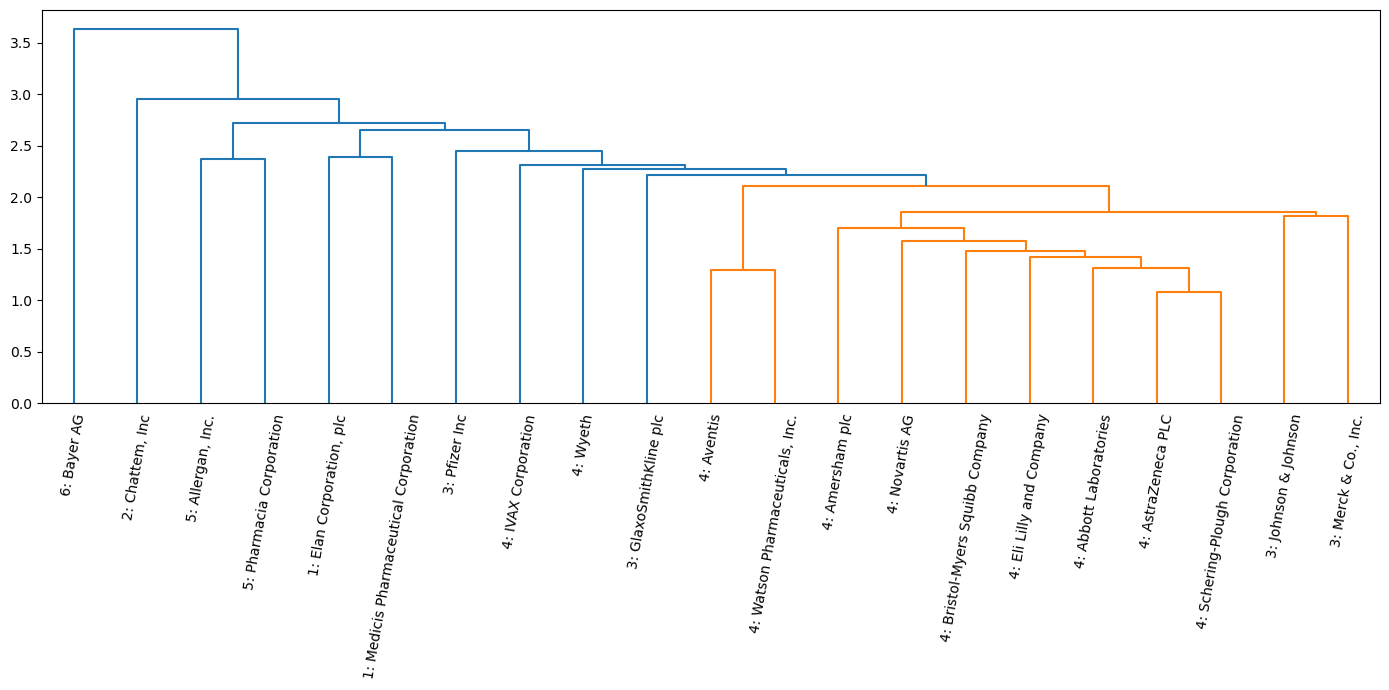

In [83]:
Z = linkage(pharm2_norm, method='single')

thr = 0.6 * Z[:,2].max()

plt.figure(figsize=(14, 7))
dendrogram(Z, labels=pharm2_norm.index, color_threshold=thr)
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

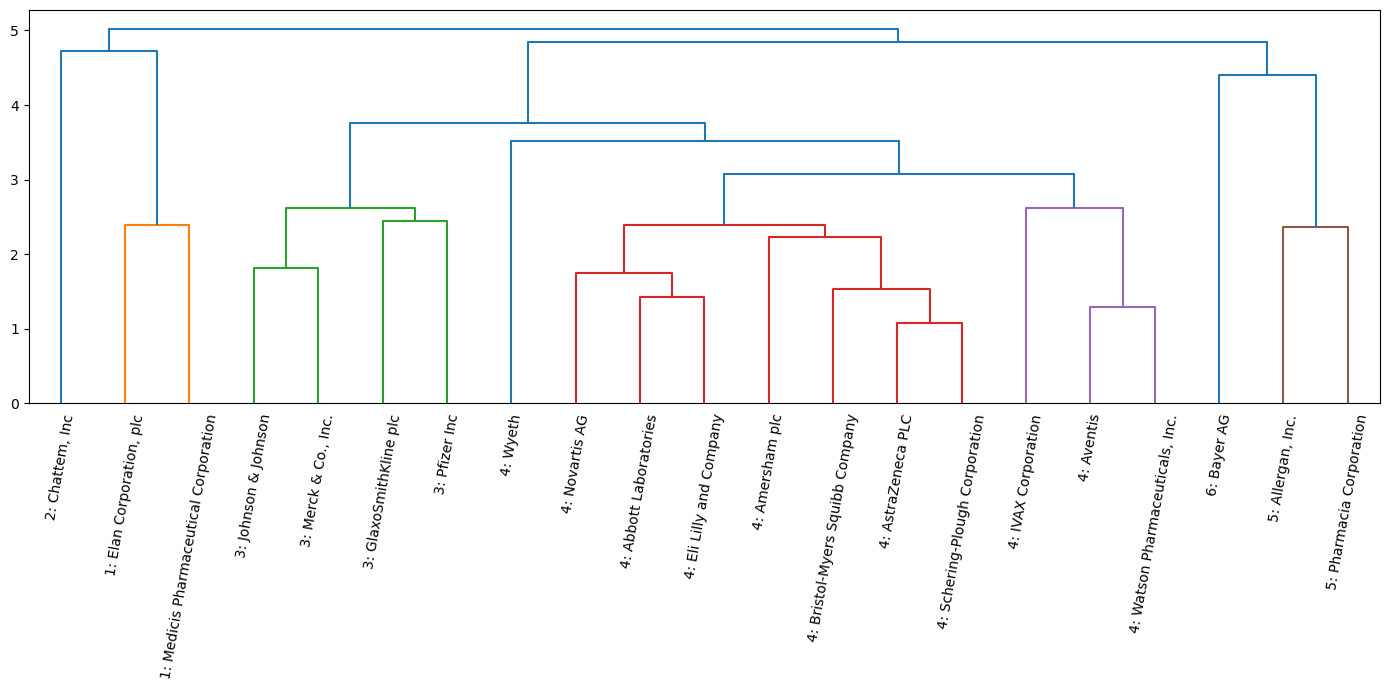

In [85]:
Z = linkage(pharm2_norm, method='average')

thr = 0.6 * Z[:,2].max()

plt.figure(figsize=(14, 7))
dendrogram(Z, labels=pharm2_norm.index, color_threshold=thr)
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

In [87]:
memb = fcluster(linkage(pharm2_norm, method= 'single'), 6, criterion= 'maxclust')
memb = pd.Series(memb, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

1 : 5: Allergan, Inc. , 5: Pharmacia Corporation
2 : 1: Elan Corporation, plc , 1: Medicis Pharmaceutical Corporation
3 : 4: Abbott Laboratories , 4: Amersham plc , 4: AstraZeneca PLC , 4: Aventis , 4: Bristol-Myers Squibb Company , 4: Eli Lilly and Company , 3: GlaxoSmithKline plc , 4: IVAX Corporation , 3: Johnson & Johnson , 3: Merck & Co., Inc. , 4: Novartis AG , 4: Schering-Plough Corporation , 4: Watson Pharmaceuticals, Inc. , 4: Wyeth
4 : 3: Pfizer Inc
5 : 2: Chattem, Inc
6 : 6: Bayer AG


In [89]:
memb = fcluster(linkage(pharm2_norm, method= 'average'), 6, criterion= 'maxclust')
memb = pd.Series(memb, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

1 : 1: Elan Corporation, plc , 1: Medicis Pharmaceutical Corporation
2 : 2: Chattem, Inc
3 : 3: GlaxoSmithKline plc , 3: Johnson & Johnson , 3: Merck & Co., Inc. , 3: Pfizer Inc
4 : 4: Abbott Laboratories , 4: Amersham plc , 4: AstraZeneca PLC , 4: Aventis , 4: Bristol-Myers Squibb Company , 4: Eli Lilly and Company , 4: IVAX Corporation , 4: Novartis AG , 4: Schering-Plough Corporation , 4: Watson Pharmaceuticals, Inc. , 4: Wyeth
5 : 5: Allergan, Inc. , 5: Pharmacia Corporation
6 : 6: Bayer AG


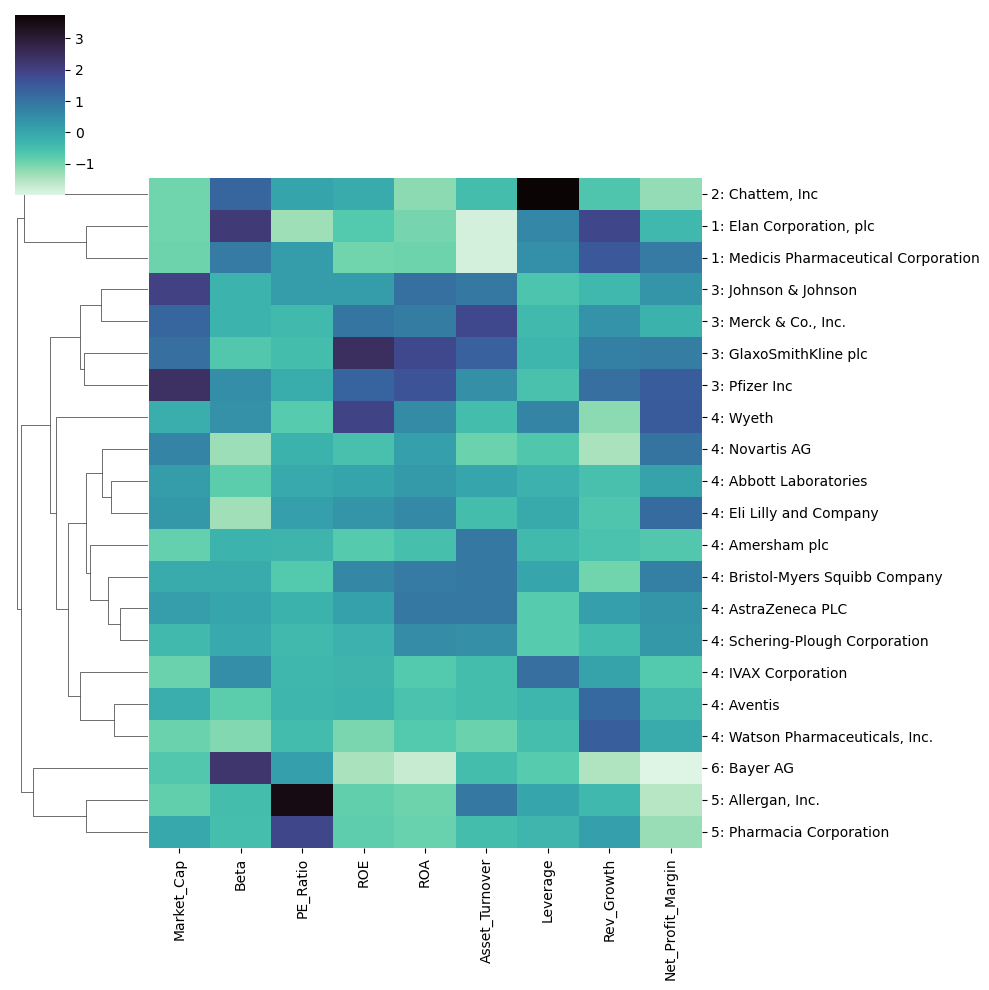

In [91]:
pharm2_norm.index = ['{}: {}'.format(cluster, state)
                     for cluster, state in zip(memb, pharm2.index)]
sns.clustermap(pharm2_norm, method='average', col_cluster=False, cmap='mako_r')

In [93]:
kmeans = KMeans(n_clusters=6, random_state=0).fit(pharm2_norm)

In [95]:
memb = pd.Series(kmeans.labels_, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print (key, ':', ','.join(item.index))

0 : 4: Amersham plc,4: Aventis,6: Bayer AG,2: Chattem, Inc,4: IVAX Corporation,4: Watson Pharmaceuticals, Inc.
1 : 3: Johnson & Johnson,3: Merck & Co., Inc.
2 : 1: Elan Corporation, plc,1: Medicis Pharmaceutical Corporation
3 : 4: Abbott Laboratories,4: AstraZeneca PLC,4: Bristol-Myers Squibb Company,4: Eli Lilly and Company,4: Novartis AG,4: Schering-Plough Corporation,4: Wyeth
4 : 3: GlaxoSmithKline plc,3: Pfizer Inc
5 : 5: Allergan, Inc.,5: Pharmacia Corporation


In [99]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=pharm2_norm.columns)
pd.set_option('display.precision', 3)
centroids

,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
0,-0.766,0.309,-0.202,-0.646,-0.892,-0.308,0.481,2.155e-04,-0.860
1,1.631,-0.256,-0.111,0.584,0.965,1.384,-0.506,-9.913e-04,0.046
2,-0.967,1.516,-0.574,-0.838,-0.989,-1.845,0.530,1.712e+00,0.245
3,0.089,-0.462,-0.321,0.326,0.540,0.066,-0.256,-7.230e-01,0.734
4,1.760,-0.100,-0.286,1.886,1.736,0.923,-0.430,9.353e-01,1.136
5,-0.439,-0.470,2.700,-0.835,-0.923,0.231,-0.142,-1.168e-01,-1.417


In [101]:
distances = kmeans.transform(pharm2_norm)

minSquaredDistances = distances.min(axis=1) ** 2

df = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
                  index=pharm2_norm.index)

for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS: 2f} within cluster')

Cluster 0 (6 members):  37.226903 within cluster
Cluster 1 (2 members):  1.645632 within cluster
Cluster 2 (2 members):  2.855389 within cluster
Cluster 3 (7 members):  16.655937 within cluster
Cluster 4 (2 members):  2.994337 within cluster
Cluster 5 (2 members):  2.803505 within cluster
